# Ant Colony Optimization

## Imports

In [1]:
import random
import time
import copy
from typing import List, Optional, Tuple
import numpy as np
import sys

sys.path.append('../data-structure')
from instance_data import InstanceData
from individual import Individual

sys.path.append('..')
from checker import check_and_evaluate

## Algorithm

In [2]:
class ACOScheduler:
    def __init__(
        self,
        instance: InstanceData,
        n_ants: int = 20,
        n_iter: int = 100,
        pheromone_weight: float = 1.0,
        heuristic_weight: float = 3.0,
        decay_rate: float = 0.1,
        acs: bool = True,
        exploitation_threshold: float = 0.9,
        ls_passes: int = 1,
        seed: Optional[int] = None,
    ):
        self.instance = instance
        self.n_ants = n_ants
        self.n_iter = n_iter
        self.pw = pheromone_weight
        self.hw = heuristic_weight
        self.decay_rate = decay_rate
        self.acs = acs
        self.q0 = exploitation_threshold
        self.ls_passes = ls_passes
        self.rng = np.random.default_rng(seed)

        if seed is not None:
            random.seed(seed)

        data = instance.json_data
        self.n = data['n']
        self.m = data['m']
        self.capable   = data['capable']
        self.duration  = data['duration']
        self.release   = data['release']
        self.setup     = data['setup']

        greedy_ind = self._greedy_individual()
        greedy_ms  = self.evaluate_individual(greedy_ind)
        self.tau0  = 1.0 / (self.n * greedy_ms) if greedy_ms > 0 else 1e-6

        self.assign_ph = [[self.tau0] * self.m for _ in range(self.n)]

        self.seq_ph = [[[self.tau0] * self.m for _ in range(self.n)]
                       for _ in range(self.n)]

    def evaluate_individual(self, individual: Individual) -> float:
        """Return the makespan of an Individual (0-indexed job ids)"""

        actual_time = 0.0

        for machine_id, machine_jobs in enumerate(individual.scheduling):
            machine_time = 0.0

            for i, job_id in enumerate(machine_jobs):
                job_release  = self.release[job_id][machine_id]
                job_duration = self.duration[job_id][machine_id]
                job_setup    = (self.setup[machine_jobs[i - 1]][job_id][machine_id] if i > 0 else 0)
                machine_time = (max(job_release, machine_time + job_setup) + job_duration)
            actual_time = max(actual_time, machine_time)

        return actual_time

    def _machine_completion(self, jobs: List[int], k: int) -> float:
        """Completion time of machine k for a given job sequence"""

        t = 0.0

        for i, j in enumerate(jobs):
            setup = self.setup[jobs[i - 1]][j][k] if i > 0 else 0
            t = max(self.release[j][k], t + setup) + self.duration[j][k]

        return t

    def _completion_if_inserted(self, jobs: List[int], k: int, job: int, pos: int) -> float:
        """Completion time of machine k if `job` is inserted at `pos`"""

        new_jobs = jobs[:pos] + [job] + jobs[pos:]

        return self._machine_completion(new_jobs, k)

    def _best_insertion_pos(self, jobs: List[int], k: int, job: int) -> Tuple[int, float]:
        """Return (best_position, resulting_completion_time) for inserting job on machine k"""

        best_pos, best_c = 0, float('inf')

        for pos in range(len(jobs) + 1):
            c = self._completion_if_inserted(jobs, k, job, pos)
            if c < best_c:
                best_c, best_pos = c, pos

        return best_pos, best_c

    def _greedy_individual(self) -> Individual:
        """Build one greedy individual: assign each job to the machine that minimises delta makespan"""

        scheduling = [[] for _ in range(self.m)]
        jobs = list(range(self.n))
        random.shuffle(jobs)

        for j in jobs:
            best_k, best_c = self.capable[j][0], float('inf')

            for k in self.capable[j]:
                _, c = self._best_insertion_pos(scheduling[k], k, j)

                if c < best_c:
                    best_c, best_k = c, k

            pos, _ = self._best_insertion_pos(scheduling[best_k], best_k, j)
            scheduling[best_k].insert(pos, j)

        return Individual(scheduling)

    def _heuristic(self, j: int, k: int, scheduling: List[List[int]]) -> float:
        """eta(j,k) = 1 / (1 + completion_if_appended_at_end)"""
        c = self._completion_if_inserted(scheduling[k], k, j, len(scheduling[k]))

        return 1.0 / (1.0 + c)

    def _select_machine(self, j: int, scheduling: List[List[int]]) -> int:
        """Pick a machine for job j using pheromone × heuristic"""
        feasible = self.capable[j]

        if self.acs and random.random() < self.q0:
            return max(feasible, key=lambda k: (self.assign_ph[j][k] ** self.pw) * (self._heuristic(j, k, scheduling) ** self.hw))

        scores = [(self.assign_ph[j][k] ** self.pw) * (self._heuristic(j, k, scheduling) ** self.hw) for k in feasible]
        total = sum(scores)

        if total == 0:
            return random.choice(feasible)

        r = random.random() * total
        cumsum = 0.0

        for k, w in zip(feasible, scores):
            cumsum += w

            if cumsum >= r:
                return k

        return feasible[-1]

    def _build_individual(self) -> Individual:
        """One ant constructs one Individual using best-insertion placement"""

        scheduling = [[] for _ in range(self.m)]
        jobs = list(range(self.n))
        random.shuffle(jobs)

        for j in jobs:
            k = self._select_machine(j, scheduling)
            pos, _ = self._best_insertion_pos(scheduling[k], k, j)
            scheduling[k].insert(pos, j)

            if self.acs:
                self.assign_ph[j][k] = ((1 - self.decay_rate) * self.assign_ph[j][k] + self.decay_rate * self.tau0)

        return Individual(scheduling)

    def _local_search(self, individual: Individual, current_ms: float) -> Tuple[Individual, float]:
        """
        Try moving each job to every feasible (machine, position).
        Accept the first move that strictly reduces makespan.
        Repeat for ls_passes passes
        """

        best = individual.copy()
        best_ms = current_ms

        for _ in range(self.ls_passes):
            improved = False

            for src_k in range(self.m):
                for src_pos in range(len(best.scheduling[src_k])):
                    j = best.scheduling[src_k][src_pos]
                    src_without_j = (best.scheduling[src_k][:src_pos] + best.scheduling[src_k][src_pos + 1:])

                    for dst_k in self.capable[j]:
                        dst_jobs = (src_without_j if dst_k == src_k else best.scheduling[dst_k])

                        for dst_pos in range(len(dst_jobs) + 1):
                            if dst_k == src_k and dst_pos == src_pos:
                                continue

                            candidate = best.copy()
                            candidate.scheduling[src_k] = src_without_j
                            new_dst = dst_jobs[:dst_pos] + [j] + dst_jobs[dst_pos:]
                            candidate.scheduling[dst_k] = new_dst

                            ms = self.evaluate_individual(candidate)

                            if ms < best_ms - 1e-9:
                                best = candidate
                                best_ms = ms
                                improved = True

                                break

                        if improved: break

                    if improved: break

                if improved: break

        return best, best_ms

    def _evaporate(self):
        for j in range(self.n):
            for k in range(self.m):
                self.assign_ph[j][k] = max(self.assign_ph[j][k] * (1 - self.decay_rate), 1e-10)

        for i in range(self.n):
            for j in range(self.n):
                for k in range(self.m):
                    self.seq_ph[i][j][k] = max(self.seq_ph[i][j][k] * (1 - self.decay_rate), 1e-10)

    def _deposit(self, individual: Individual, makespan: float):
        delta = 1.0 / makespan

        for k, jobs in enumerate(individual.scheduling):
            prev = None

            for j in jobs:
                self.assign_ph[j][k] += delta

                if prev is not None:
                    self.seq_ph[prev][j][k] += delta

                prev = j

    def run(self) -> Tuple[dict, List[float]]:
        """Runs the ACO"""

        best_individual: Optional[Individual] = None
        best_ms = float('inf')
        history: List[float] = []

        for iteration in range(self.n_iter):
            iter_best_ind: Optional[Individual] = None
            iter_best_ms = float('inf')

            for _ in range(self.n_ants):
                ind = self._build_individual()
                ms = self.evaluate_individual(ind)

                if self.ls_passes > 0:
                    ind, ms = self._local_search(ind, ms)

                if ms < iter_best_ms:
                    iter_best_ms = ms
                    iter_best_ind = ind.copy()

            if iter_best_ms < best_ms:
                best_ms = iter_best_ms
                best_individual = iter_best_ind.copy()

            self._evaporate()
            self._deposit(best_individual, best_ms)

            history.append(best_ms)

            if (iteration + 1) % 10 == 0:
                print(f"  Iter {iteration + 1:4d}/{self.n_iter}"
                      f"  |  best makespan = {int(best_ms)}")

        return best_individual.format_solution(best_ms), history


## Testing

In [3]:
instance = InstanceData('../examples/75_3_5_H.json')

print(instance.json_data)

{'n': 5, 'm': 3, 'horizon': 1664, 'capable': [[2], [2], [2], [2], [2, 0, 1]], 'duration': [[175, 465, 352], [365, 452, 244], [193, 198, 156], [471, 281, 87], [57, 62, 59]], 'release': [[254, 122, 76], [67, 36, 83], [288, 23, 138], [141, 231, 341], [202, 20, 170]], 'setup': [[[0, 0, 0], [41, 93, 3], [32, 75, 67], [59, 56, 70], [61, 91, 78]], [[74, 3, 14], [0, 0, 0], [5, 7, 55], [4, 71, 83], [76, 94, 82]], [[37, 71, 2], [88, 13, 8], [0, 0, 0], [100, 97, 93], [10, 29, 72]], [[48, 84, 81], [95, 24, 85], [1, 27, 84], [0, 0, 0], [51, 77, 41]], [[59, 29, 10], [66, 28, 20], [85, 74, 49], [72, 79, 18], [0, 0, 0]]]}



  SMALL INSTANCE  (5 jobs, 3 machines)
  Iter   10/50  |  best makespan = 1049
  Iter   20/50  |  best makespan = 1049
  Iter   30/50  |  best makespan = 1049
  Iter   40/50  |  best makespan = 1049
  Iter   50/50  |  best makespan = 1049

  Best makespan : 1049
  Runtime       : 0.1s
  Checker       : feasible=True, makespan=1049
  Schedule      : {'0': [], '1': [5], '2': [2, 3, 1, 4]}


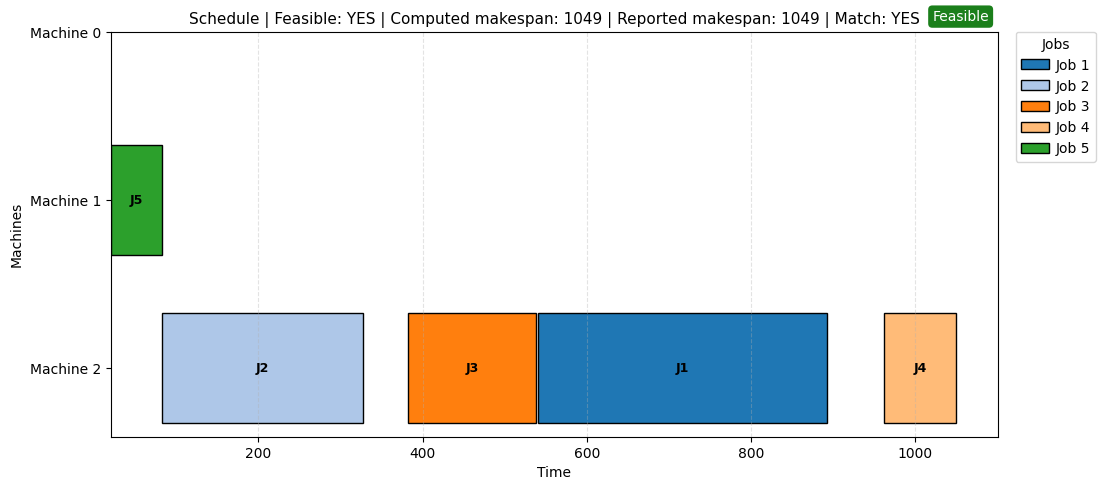

{'feasible': True,
 'checker_result': 1049,
 'reported_makespan': 1049,
 'computed_makespan': 1049}

In [ ]:
import sys
sys.path.insert(0, '/home/ravenne/Downloads/Parallel-Machine-Scheduling/')
sys.path.insert(0, '/home/ravenne/Downloads/Parallel-Machine-Scheduling/data-structure')
from checker import check_and_evaluate

from scheduler_plot import plot_schedule_from_json

# ── Small instance ──────────────────────
print("\n" + "="*55)
print("  SMALL INSTANCE  (5 jobs, 3 machines)")
print("="*55)

instance = InstanceData('../examples/75_3_5_H.json')
aco = ACOScheduler(instance, n_ants=15, n_iter=50, heuristic_weight=3.0, acs=True, ls_passes=1, seed=42)
t0 = time.time()
solution, history = aco.run()

print(f"\n  Best makespan : {solution['makespan']}")
print(f"  Runtime       : {time.time() - t0:.1f}s")

feasible, result = check_and_evaluate(instance.json_data, solution)

print(f"  Checker       : feasible={feasible}, makespan={result}")
print(f"  Schedule      : {solution['schedule']}")

plot_schedule_from_json(instance_path=instance.json_data, solution_path=solution)

# ── Hard instance ───────────────────────
print("\n" + "="*55)
print("  HARD INSTANCE  (146 jobs, 15 machines)")
print("="*55)

hard_instance = InstanceData('../examples/357_15_146_H.json')
aco_hard = ACOScheduler(hard_instance, n_ants=20, n_iter=100, heuristic_weight=3.0, acs=True, ls_passes=1, seed=42)
t0 = time.time()
solution_hard, history_hard = aco_hard.run()

print(f"\n  Best makespan : {solution_hard['makespan']}")
print(f"  Runtime       : {time.time() - t0:.1f}s")

feasible, result = check_and_evaluate(hard_instance.json_data, solution_hard)

print(f"  Checker       : feasible={feasible}, makespan={result}")

plot_schedule_from_json(instance_path=hard_instance.json_data, solution_path=solution_hard)